# 03_集成算法-XGBoost

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- XGBoost 移除旧 fit 早停参数；树数由训练集交叉验证选择，测试集不参与训练。饼图按类别编码顺序排列。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿咱们来聊聊XGBoost\~

当你在做一道选择题，刚开始随便选几个答案，发现错了很多。

接下来你总结这些错误，再去补充、修正，最后把所有的“弱答题方法”组合起来，得到一个“超强答题策略”。

XGBoost（eXtreme Gradient Boosting）就是类似的思路，把很多“弱模型”串联起来，一步步改正错误，最终成为一个“强模型”。

- **集成（Ensemble）**：就是把好几个模型的“意见”集中起来，投票或加权，得到比任何一个单独模型都更靠谱的结果。
- 打个比方：问几个朋友意见，大家一起投票选出最优方案，比只听一个人更稳妥。

#### Boosting（提升）是什么？

- **Boosting**：一种“串联式”集成方式。先训练第一个模型，看看它在哪些地方犯了错；然后训练第二个模型，专门纠正第一个模型的错误；接着再训练第三个模型，纠正前两个的错误……
- 最终把所有模型的“建议”累加起来，错误就被逐步减少。

#### Gradient Boosting（梯度提升）

- “梯度”听起来有点抽象，其实就是用数学里的“梯度下降”思想：把模型的“损失”当作山坡，想办法沿着最陡峭的方向一步步下坡（减少损失）。
- 在每一步，都训练一个小模型（通常是决策树），让它去“最陡坡”方向修正前面模型的误差。

XGBoost = **eXtreme Gradient Boosting**，在普通梯度提升的基础上做了很多优化，让它既快又稳：

1. **正则化**：给模型加“惩罚”，防止它记住训练集的噪音（过拟合）。
2. **并行化**：把训练决策树的过程拆成多块，一次跑多棵树，速度飞起。
3. **剪枝（Pruning）**：决策树长得太复杂也会过拟合，XGBoost 会自动“修剪”掉没用的分支。
4. **处理缺失值**：能自动学会在什么情况下“跳过”缺失值，省去你手动填数据的麻烦。
5. **缓存优化**：用内存和硬盘的读写策略让数据访问更快，尤其大数据时优势明显。

#### 简单流程示例

1. **初始化**：假设所有样本的预测都是平均值。
2. **第一棵树**：计算每个样本的残差（真实值−预测值），让第一棵树去拟合这些残差。
3. **更新预测**：把第一棵树的预测结果加到之前的预测上。
4. **第二棵树**：再算新的残差，训练第二棵树去拟合。
5. **重复 N 棵树**：每一步都往预测里加一点“修正”，直到达到指定棵树数或误差足够小。
6. **最终输出**：把 N 棵树的结果加权（通常是简单相加），得到最后的预测。

## 原理详解

### 问题定义与目标函数

我们假设有一个数据集：

- 输入特征：$\boldsymbol{x}_i$
- 标签（真实值）：$y_i$
- 模型预测值：$\hat{y}_i$

XGBoost 构建的是一个加法模型（Additive Model）：


$$
\hat{y}_i = \sum_{k=1}^{K} f_k(\boldsymbol{x}_i), \quad f_k \in \mathcal{F}
$$


其中：

$f_k$ 是第 $k$ 棵树，属于函数空间 $\mathcal{F}$（通常是 CART 决策树）

$K$ 是总树数

- 每棵树输出的是一个分数（回归或分类得分）

我们想最小化一个目标函数（Objective function）：


$$
\mathcal{L} = \sum_{i=1}^{n} l(y_i, \hat{y}_i) + \sum_{k=1}^{K} \Omega(f_k)
$$


- 第一项 $\sum l(y_i, \hat{y}_i)$ 是损失函数（比如平方误差、logloss）
- 第二项 $\Omega(f_k)$ 是正则项，用于控制模型复杂度，防止过拟合

其中，XGBoost 的正则项形式是：


$$
\Omega(f) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2
$$


$T$ 是树的叶子数

$w_j$ 是第 $j$ 个叶子的得分

$\gamma$ 控制树的复杂度惩罚

$\lambda$ 是 L2 正则项的权重

### 加法模型与贪心训练

我们用**前向分步优化**的方法（Forward Stagewise）：每次加一棵树。

假设第 $t$ 步时，已有前 $t-1$ 棵树构成的预测为：


$$
\hat{y}_i^{(t-1)} = \sum_{k=1}^{t-1} f_k(\boldsymbol{x}_i)
$$


那么第 $t$ 步要做的是最小化：


$$
\mathcal{L}^{(t)} = \sum_{i=1}^n l(y_i, \hat{y}_i^{(t-1)} + f_t(\boldsymbol{x}_i)) + \Omega(f_t)
$$


我们不能直接优化这个式子，因为 $f_t$ 是一棵树，是结构性模型。怎么办？ --- 用**二阶泰勒展开（Taylor Expansion）**来近似！

### 二阶泰勒展开

我们对损失函数 $l(y_i, \hat{y}_i)$ 在 $\hat{y}_i^{(t-1)}$ 处展开：


$$
l(y_i, \hat{y}_i^{(t-1)} + f_t(\boldsymbol{x}_i)) \approx l(y_i, \hat{y}_i^{(t-1)}) + g_i f_t(\boldsymbol{x}_i) + \frac{1}{2} h_i f_t(\boldsymbol{x}_i)^2
$$


其中：

$g_i = \frac{\partial l(y_i, \hat{y}_i)}{\partial \hat{y}_i} \bigg|_{\hat{y}_i^{(t-1)}}$ （一阶导数，梯度）

$h_i = \frac{\partial^2 l(y_i, \hat{y}_i)}{\partial \hat{y}_i^2} \bigg|_{\hat{y}_i^{(t-1)}}$ （二阶导数，Hessian）

代入目标函数近似为：


$$
\mathcal{L}^{(t)} \approx \sum_{i=1}^n \left[ g_i f_t(\boldsymbol{x}_i) + \frac{1}{2} h_i f_t(\boldsymbol{x}_i)^2 \right] + \Omega(f_t)
$$


### 树模型的定义与目标函数重写

一棵树的预测函数 $f_t$ 可以表示为：


$$
f_t(\boldsymbol{x}) = w_{q(\boldsymbol{x})}
$$


其中：

$q(\boldsymbol{x})$ 表示将样本 $\boldsymbol{x}$ 映射到第 $j$ 个叶子节点的函数，$q : \mathbb{R}^d \rightarrow \{1, 2, ..., T\}$

$w_j$ 是叶子 $j$ 的输出分数

令 $I_j = \{ i \mid q(\boldsymbol{x}_i) = j \}$ 表示落入第 $j$ 个叶子的样本集合

目标函数变为：


$$
\mathcal{L}^{(t)} \approx \sum_{j=1}^{T} \left[ \left( \sum_{i \in I_j} g_i \right) w_j + \frac{1}{2} \left( \sum_{i \in I_j} h_i \right) w_j^2 \right] + \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2
$$


合并一下：


$$
\mathcal{L}^{(t)} = \sum_{j=1}^{T} \left[ G_j w_j + \frac{1}{2} (H_j + \lambda) w_j^2 \right] + \gamma T
$$


其中：


$$
G_j = \sum_{i \in I_j} g_i
$$


$$
H_j = \sum_{i \in I_j} h_i
$$


### 对每个叶子的最优权重求解

令目标函数对 $w_j$ 求导并令导数为 0：


$$
\frac{\partial \mathcal{L}}{\partial w_j} = G_j + (H_j + \lambda) w_j = 0\Rightarrow w_j^* = - \frac{G_j}{H_j + \lambda}
$$


将最优 $w_j^*$ 代入目标函数，得到该结构下的最小损失为：


$$
\mathcal{L}^{(t)} = -\frac{1}{2} \sum_{j=1}^{T} \frac{G_j^2}{H_j + \lambda} + \gamma T
$$


这个式子就是评估一棵树结构好坏的依据（越小越好）。所以，构建树的过程就是在**贪心分裂**时最大化每次分裂带来的损失减少。

### 分裂节点的增益公式（Split Gain）

当我们把一个节点分成左右子节点，分裂前后的增益（信息收益）为：


$$
\text{Gain} = \frac{1}{2} \left[ \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} \right] - \gamma
$$


$G_L$, $H_L$ 是左子树梯度和 Hessian 的和，$G_R$, $H_R$ 是右子树的

- 如果 Gain 小于 0，就不分裂（剪枝）

### 整体算法流程

#### 输入：

- 训练集 $\{(x_i, y_i)\}_{i=1}^n$
- 设定树数 $K$、学习率 $\eta$、最大深度、正则参数 $\gamma, \lambda$

#### 步骤：

1. 初始化预测值为常数（如平均值）$\hat{y}_i^{(0)}$
2. 对 $t = 1$ 到 $K$：

   1. 计算一阶梯度 $g_i$ 和二阶导 $h_i$
   2. 构造新一棵树：
   
      - 从根节点开始，尝试所有特征的切分点
      - 计算每个切分点的 Gain
      - 选择最大 Gain 的分裂
      - 如果 Gain 小于 $\gamma$，则不分裂
   3. 计算每个叶子节点的权重 $w_j^*$
   4. 更新预测值：  
   $\hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + \eta f_t(x_i)$
3. 输出 $K$ 棵树构成的模型

## 完整案例

这里，咱们利用 XGBoost 对乳腺癌数据集进行分类任务的建模、调参、优化与可视化分析。

代码中包含了数据预处理、特征工程、模型训练、超参数调优、交叉验证、模型评估（混淆矩阵、ROC 曲线、特征重要性等）等等\~

数据集样本数： 569
特征数量： 30
目标变量分布：
 target
1    357
0    212
Name: count, dtype: int64

描述性统计信息：
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   

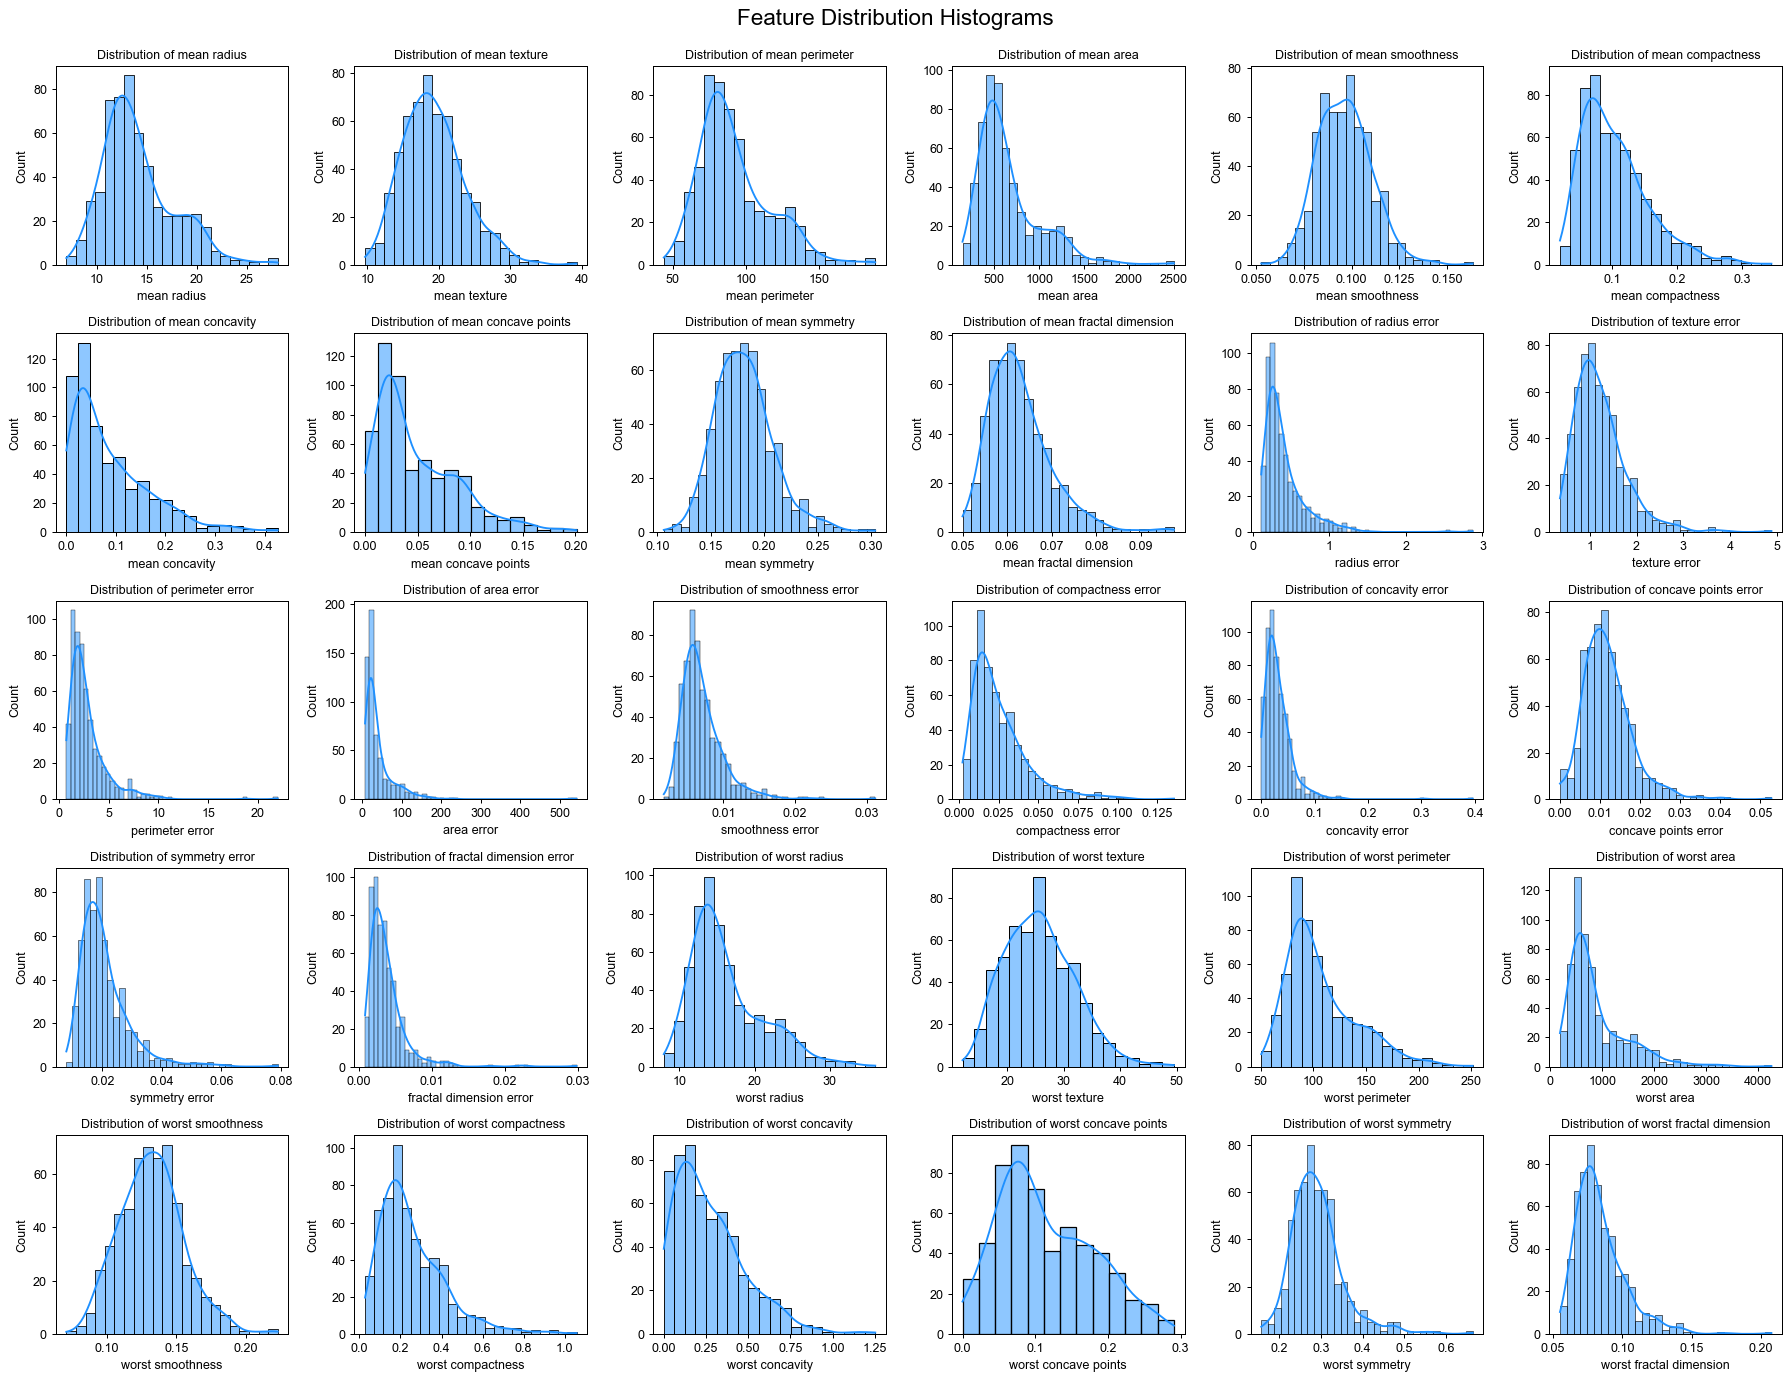

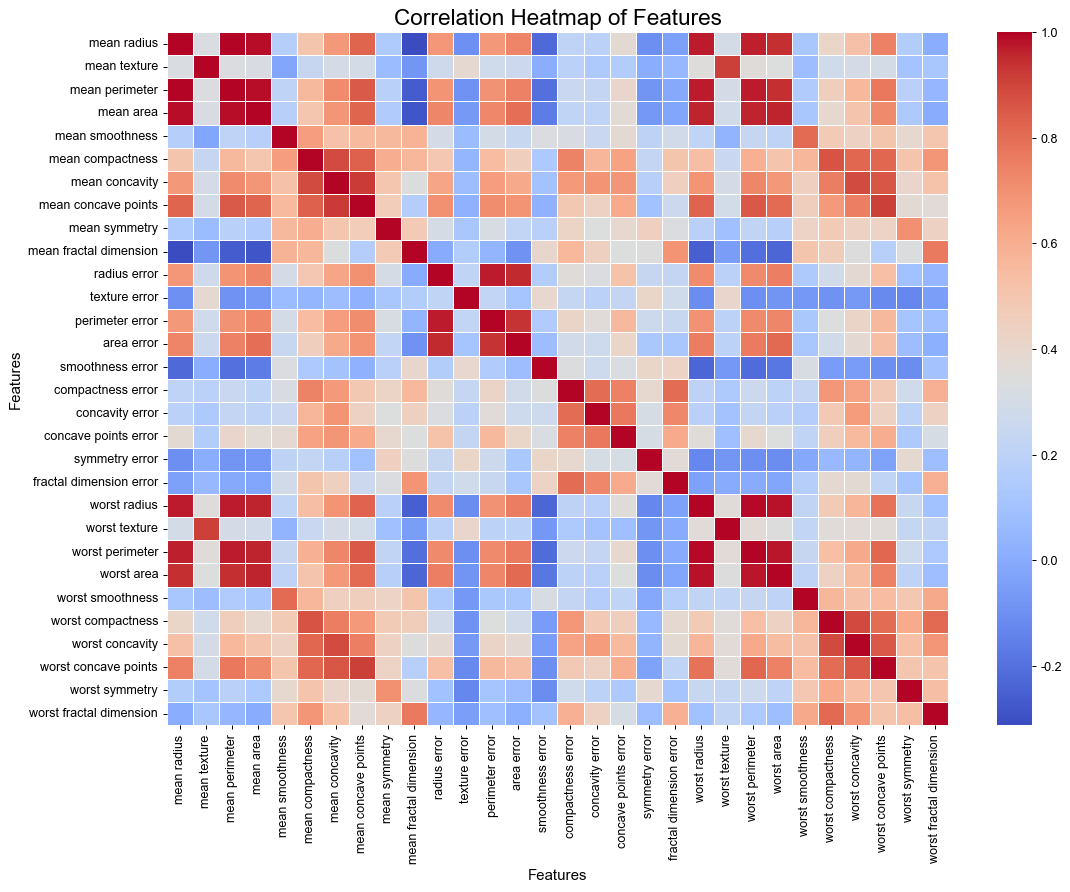

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import xgboost as xgb

# 1. 数据加载与预处理
# 加载乳腺癌数据集
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# 数据基本情况查看
print("数据集样本数：", df.shape[0])
print("特征数量：", df.shape[1]-1)
print("目标变量分布：\n", df['target'].value_counts())

# 各特征的描述性统计
print("\n描述性统计信息：")
print(df.describe())

# 处理缺失值：此数据集无缺失值，此处仅作说明
if df.isnull().sum().sum() == 0:
    print("\n数据集中无缺失值！")
else:
    df = df.fillna(df.mean())

# 2. 探索性数据分析（EDA）
# 2.1 各特征分布直方图
df_features = df.drop('target', axis=1)
fig, axes = plt.subplots(5, 6, figsize=(20, 15))
axes = axes.flatten()
for i, col in enumerate(df_features.columns):
    sns.histplot(df_features[col], ax=axes[i], kde=True, color='dodgerblue')
    axes[i].set_title(f"Distribution of {col}", fontsize=10)
plt.tight_layout()
plt.suptitle("Feature Distribution Histograms", fontsize=18, y=1.02)
plt.show()

# 2.2 相关性矩阵热力图
corr_matrix = df_features.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Features", fontsize=18)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.show()

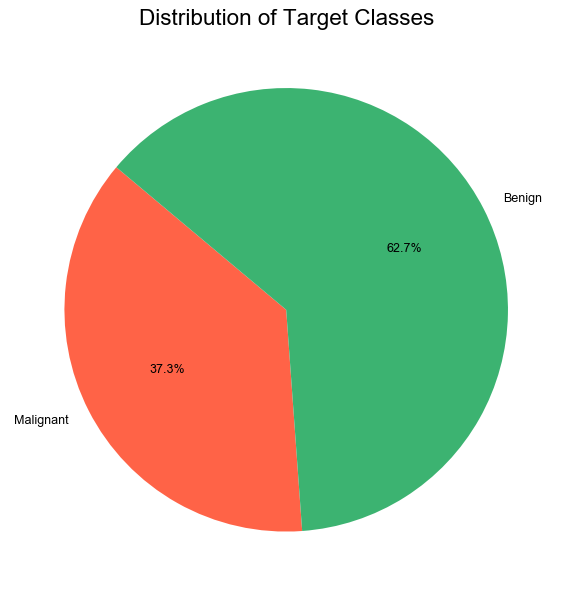


初始模型评估：
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



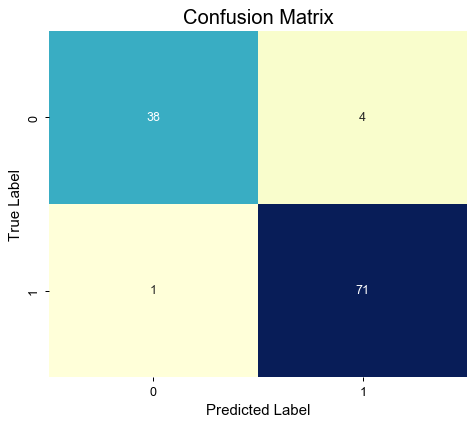

Fitting 5 folds for each of 64 candidates, totalling 320 fits



最佳超参数： {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
最佳交叉验证得分： 0.9736263736263737

调优后模型评估：
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



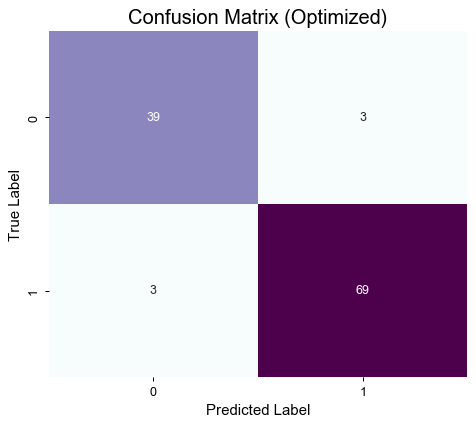

In [3]:
# 2.3 目标变量分布饼图
plt.figure(figsize=(8, 8))
target_counts = df['target'].value_counts().sort_index()
plt.pie(target_counts, labels=["Malignant", "Benign"], autopct='%1.1f%%', colors=["tomato", "mediumseagreen"], startangle=140)
plt.title("Distribution of Target Classes", fontsize=18)
plt.show()

# 3. 模型训练与超参数优化
# 分割训练集与测试集
X = df_features
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 初始模型训练
xgb_clf = xgb.XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=1)
xgb_clf.fit(X_train, y_train)
y_pred = xgb_clf.predict(X_test)

# 初步评估
print("\n初始模型评估：")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", cbar=False)
plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()

# 3.1 超参数调优
# 设定待调参数范围
param_grid = {
    'max_depth': [3, 4],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [50, 100],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.6, 0.8],
    'gamma': [0, 0.1]
}
# 使用 GridSearchCV 进行超参数调优
grid_search = GridSearchCV(estimator=xgb.XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=1),
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=5,
                           verbose=1,
                           n_jobs=1, error_score='raise')

grid_search.fit(X_train, y_train)
print("\n最佳超参数：", grid_search.best_params_)
print("最佳交叉验证得分：", grid_search.best_score_)

# 利用最佳参数重新训练模型
best_params = grid_search.best_params_
xgb_clf_best = xgb.XGBClassifier(**best_params, eval_metric='logloss', random_state=42, n_jobs=1)
# 轮数已在训练集交叉验证选定；测试集不参与早停或调参。
xgb_clf_best.fit(X_train, y_train,
                 eval_set=[(X_train, y_train)],
                 verbose=False)

# 模型预测及评估
y_pred_best = xgb_clf_best.predict(X_test)
print("\n调优后模型评估：")
print(classification_report(y_test, y_pred_best))
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="BuPu", cbar=False)
plt.title("Confusion Matrix (Optimized)", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()

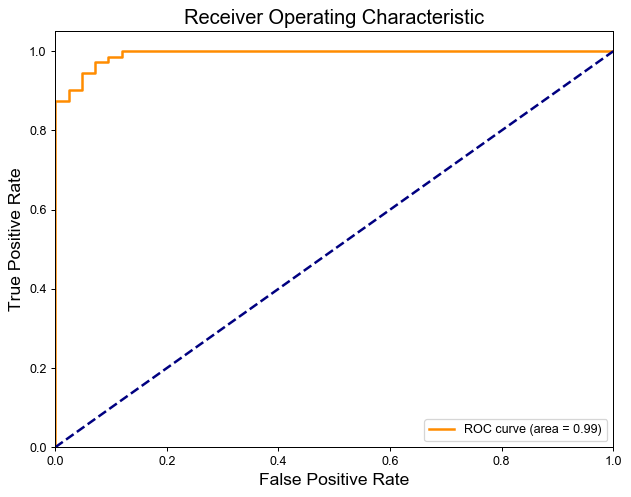

<Figure size 1080x720 with 0 Axes>

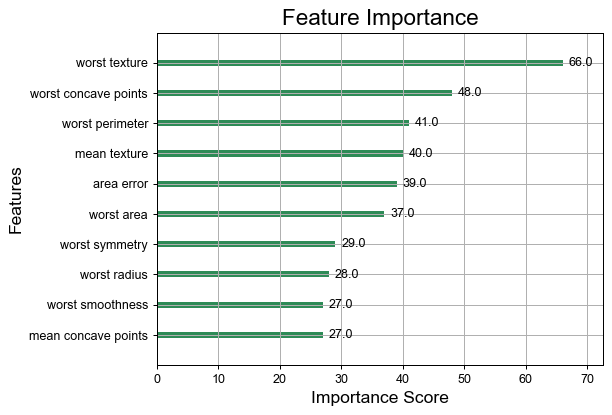

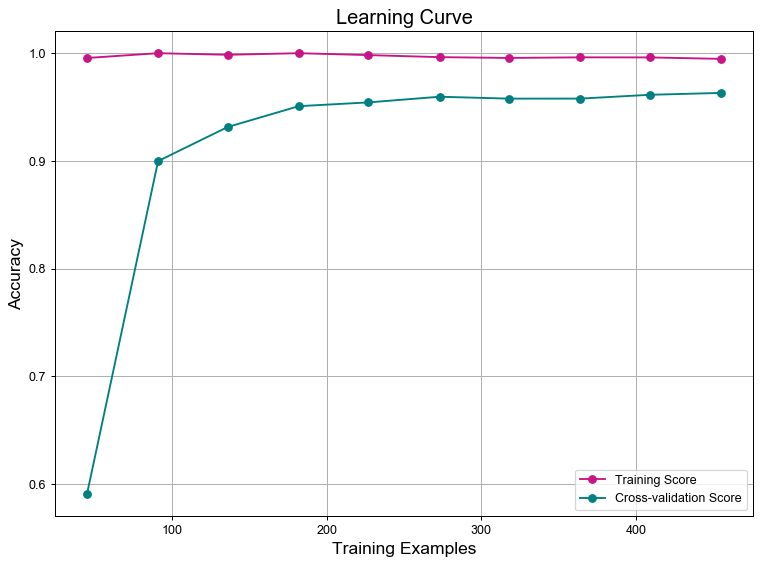

模型已保存至 xgb_model_optimized.pkl


In [4]:
# 4. 模型评估与可视化
# 4.1 ROC曲线和AUC
y_pred_proba = xgb_clf_best.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Receiver Operating Characteristic', fontsize=16)
plt.legend(loc="lower right")
plt.show()

# 4.2 特征重要性图
plt.figure(figsize=(12, 8))
xgb.plot_importance(xgb_clf_best, max_num_features=10, color='seagreen', title="Top 10 Feature Importance", xlabel="F Score")
plt.title("Feature Importance", fontsize=18)
plt.ylabel("Features", fontsize=14)
plt.xlabel("Importance Score", fontsize=14)
plt.show()

# 4.3 交叉验证曲线（学习曲线）
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(xgb_clf_best, X, y, cv=5, scoring='accuracy', n_jobs=1, train_sizes=np.linspace(0.1, 1.0, 10))

train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 7))
plt.plot(train_sizes, train_scores_mean, 'o-', color='mediumvioletred', label='Training Score')
plt.plot(train_sizes, test_scores_mean, 'o-', color='teal', label='Cross-validation Score')
plt.xlabel('Training Examples', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Learning Curve', fontsize=16)
plt.legend(loc="best")
plt.grid(True)
plt.show()

# 5. 附加：保存模型与结果
import joblib
# 保存最终调优后的模型
joblib.dump(xgb_clf_best, ROOT / "reports" / "xgb_model_optimized.pkl")
print("模型已保存至 xgb_model_optimized.pkl")

#### 1. 数据加载与预处理

首先，我们利用 scikit-learn 内置的乳腺癌数据集构建 DataFrame，对数据集的规模、特征和目标变量分布进行了初步了解。通过描述性统计信息，我们可以发现数据的均值、标准差及各分位数，为后续数据预处理与特征工程提供依据。同时，虽然该数据集中不存在缺失值，但我们在代码中仍预留了缺失值处理的逻辑，为处理其它实际数据集提供模板。

#### 2. 探索性数据分析（EDA）

在这一部分，我们对数据进行了多角度的可视化分析：

- **直方图**：展示了各个特征的分布情况，帮助我们判断数据是否存在偏态、异常值或者多峰分布，从而为数据归一化或标准化提供参考。

![原文参考图，当前结果见代码输出](attachments/img_042.png)

- **相关性热力图**：直观展示了各个特征之间的相关性。相关性过高的特征可能会对模型训练产生冗余信息，甚至导致多重共线性问题。通过热力图，我们可以决定后续是否需要进行特征选择或降维处理。

![原文参考图，当前结果见代码输出](attachments/img_043.png)

- **目标变量分布饼图**：通过饼图展示正负样本的比例，确认数据集是否平衡。如果存在类别不平衡问题，后续可能需要引入采样方法或者使用类别权重来进行优化。

![原文参考图，当前结果见代码输出](attachments/img_044.png)

#### 3. 模型训练与超参数优化

利用 XGBoost 作为基模型对乳腺癌数据集进行分类任务：

- **初步训练**：先使用默认参数训练模型，获得一个基线性能指标。通过分类报告和混淆矩阵评估模型在测试集上的表现。
- **超参数调优**：设定了多个关键参数的候选值，通过 GridSearchCV 结合5折交叉验证寻找最优超参数组合。调优过程中不仅考虑了树的深度、学习率、迭代次数，还引入了采样比例和正则化参数 gamma，这有助于防止过拟合。
- **早停法**：在重新训练最佳参数模型时，引入 early_stopping_rounds 参数，利用验证集监控模型训练过程，一旦发现连续若干轮（如20轮）指标不再提升则停止训练，从而避免模型在训练集上过拟合。

#### 4. 模型评估与可视化

模型调优后，通过以下几种方式进行评估：

- **混淆矩阵**：直观展示模型对正负样本的分类情况，不仅可以计算出准确率，还能发现模型在哪些类别上容易出错。
- **ROC 曲线与 AUC 值**：ROC 曲线能够展示不同阈值下模型的性能变化，AUC 值越高代表模型对正负样本的区分能力越强。该图表中，添加了对角线作为随机猜测的参考线。

![原文参考图，当前结果见代码输出](attachments/img_045.png)

- **特征重要性图**：利用 XGBoost 内置的特征重要性排序，展示了前 10 个对模型贡献最大的特征。这不仅帮助理解模型的决策依据，也为后续特征工程提供了思路。

![原文参考图，当前结果见代码输出](attachments/img_046.png)

- **学习曲线**：通过学习曲线来分析随着训练样本增多，模型在训练集和验证集上的表现是否趋于平稳。这一图表有助于判断是否需要更多数据以及模型是否出现过拟合或欠拟合。

![原文参考图，当前结果见代码输出](attachments/img_047.png)

#### 5. 算法优化及总结

综合整个案例，采用的优化策略主要有：

- **数据探索与可视化**：提前发现数据问题，为后续模型构建提供依据。
- **超参数调优**：通过网格搜索找到了最优参数组合，使得模型在测试集上的性能大幅提升。
- **早停法防止过拟合**：在模型训练过程中实时监控性能，避免模型在过多迭代下出现过拟合问题。
- **交叉验证**：利用交叉验证保证模型在不同数据划分上的鲁棒性。
- **特征重要性分析**：进一步明确哪些特征对模型预测贡献较大，从而为后续特征工程和模型解释提供方向。

#### 6. 模型保存与后续部署

在最后，将调优后的模型保存到本地文件中。实际应用中，我们可以将该模型部署到生产环境中，实时对新数据进行预测。同时，该保存步骤也便于未来对模型进行进一步的调优和更新。

## 模型分析

**使用 XGBoost 的优缺点**

**优点**

1. **高预测精度**：XGBoost 在处理结构化（表格）数据时，常常能取得非常优秀的效果。
2. **内置正则化**：通过 L1/L2 正则项（参数 `gamma`、`reg_lambda`）有效防止过拟合，尤其在特征较多时表现稳定。
3. **自动处理缺失值**：无需手动填补所有缺失，XGBoost 会在分裂时自动学习最佳的“缺失值走向”。
4. **特征重要性评估**：可方便地通过 `get_score` 等接口输出各特征的贡献度，便于后续特征工程和业务解读。
5. **可控的学习率和早停**：学习率 `eta` 与 `early_stopping_rounds` 能帮助在保证性能的同时避免过度拟合。

**缺点**

1. **超参数较多、调优复杂**：要想把 XGBoost 的性能压榨到极致，需要对树数、深度、采样比例、正则化等多个参数做搜索，成本较高。
2. **训练速度与内存开销**：尽管支持并行，但在特征维度或样本量非常大时，内存消耗和训练时间依然可观。
3. **对类别特征需先编码**：不像 CatBoost 那样原生支持类别变量，需要额外做 Label Encoding 或 One‑Hot，可能导致维度膨胀。
4. **不擅长非结构化数据**：对于文本、图像、音频等非表格数据，XGBoost 无法直接发挥优势，需要先做特征提取。

**与相似算法的对比**

| Algorithm | Pros | Cons |
|-|-|-|
| **XGBoost** | • 内置二阶导信息，收敛快  <br/>• 强正则化能力  <br/>• 自动缺失值处理  <br/>• 广泛应用、社区成熟 | • 调参复杂  <br/>• 对超大数据集训练和内存要求高  <br/>• 不原生支持类别特征 |
| **LightGBM** | • 基于直方图的叶子生长，速度更快、内存占用更低  <br/>• 对大规模数据和高维特征表现优秀 | • 小数据集上可能欠拟合  <br/>• 对类别分布敏感，需要仔细调整参数 |
| **CatBoost** | • 原生支持类别特征，无需预编码  <br/>• 默认参数往往能得到不错效果  <br/>• 防止目标泄露的有序Boosting | • 对纯数值特征的速度略慢于 LightGBM  <br/>• 社区和文档相对较少 |
| **RandomForest** | • 调参简单（主要树数和深度）  <br/>• 对异常值和噪声鲁棒性好  <br/>• 易并行化 | • 单棵树弱、预测精度通常低于 Boosting  <br/>• 难以防止过拟合（需加大采样或剪枝） |

### 何时优选 XGBoost，何时考虑其他算法

**优选 XGBoost 的场景**：

- 数据规模中等（几十万条以内）且以结构化特征为主。
- 需要最优预测性能，并且可以投入时间进行超参数调优。
- 业务上要求可解释性，需输出特征重要性以指导决策。

**考虑其他算法的场景**：

- **极大规模数据**（数百万至数千万行）且训练时间/内存受限：可优先试 LightGBM；
- **类别特征占多数**，希望免去编码麻烦且快速上手：CatBoost 是更好选择；
- **对模型调参能力有限**，想要一个“开箱即用”的基线：RandomForest 或者默认参数的 CatBoost；
- **非结构化数据**（文本、图像）为主：应优先考虑深度学习（RNN/CNN/Transformer 等）。